In [6]:
import eos
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
from IPython.display import display, Latex
#import re
import yaml
#from tabulate import tabulate
from wquantiles import quantile
from collections import OrderedDict
from scipy import integrate
import mpmath as mp
import sympy as sp

import chi_OPE as chi

BASE_DIRECTORY='./data_base'
TEST_BASE_DIRECTORY='./test_base'
ANALYSIS_FILE='./an_file.yaml'

def weighted_mean_std(samples, weights):
    mean = np.average(samples, weights=weights)
    var = np.average((samples - mean) ** 2, weights=weights)
    return mean, np.sqrt(var)

def find_index_for_q2(prediction, obs_name, q2_value):
    candidates = []
    for idx, item in enumerate(prediction.varied_parameters):
        if item.get('name') != obs_name:
            continue
        kin = item.get('kinematics', {})
        if 'q2' in kin:
            candidates.append((idx, float(kin['q2'])))
    if not candidates:
        return None, None
    idx, q2_best = min(candidates, key=lambda t: abs(t[1] - q2_value))
    return idx, q2_best

def range_from_pred(prediction, obs_name, q2_vals, nsigma=3.0, pad_frac=0.1):
    vals = []
    for q2 in q2_vals:
        idx, _ = find_index_for_q2(prediction, obs_name, q2)
        if idx is None:
            continue
        mean, std = weighted_mean_std(prediction.samples[:, idx], prediction.weights)
        vals.extend([mean - nsigma * std, mean + nsigma * std])
    if not vals:
        return [0.0, 1.0]
    vmin, vmax = min(vals), max(vals)
    pad = (vmax - vmin) * pad_frac if vmax != vmin else max(abs(vmin) * pad_frac, 1e-4)
    return [vmin - pad, vmax + pad]

def print_params_from_posterior(base, posterior):
    posterior_dir = os.path.join(base, 'data', posterior, 'samples')

    data = eos.data.ImportanceSamples(posterior_dir)
    samples = data.samples
    weights = data.weights
    varied = [p["name"] for p in data.varied_parameters]
    for name in varied:
        idx = varied.index(name)
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{name}: {mean:e} ± {std:.2e}")

def print_pred_from_posterior(base, posterior, pred_name, obs_name, q2_vals):
    pred_dir = os.path.join(base, 'data', posterior, f'pred-{pred_name}')
    data = eos.data.Prediction(pred_dir)
    samples = data.samples
    weights = data.weights

    idx_q2best = []
    for q2 in q2_vals:
        idx, q2_best = find_index_for_q2(data, obs_name, q2)
        if idx is not None:
            idx_q2best.append((idx, q2_best))
    if not idx_q2best:
        print(f"No entries found for {obs_name} in {pred_name}")
        return
    for idx, q2_best in idx_q2best:
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{obs_name} at q^2={q2_best:.1f}: {mean:e} ± {std:.2e}")

$\chi_{OPE}$ is implemented in the imported ```chi_OPE.py```.
Args: subtraction point, s0 

In [ ]:
#display(chi.chi_OPE(0, (chi.mb + chi.ms)**2)) # (WORKS)

(0.0002665870319564172, 1.1413012951377866e-08)

$t=q^2$, $M\;m$ are the meson masses

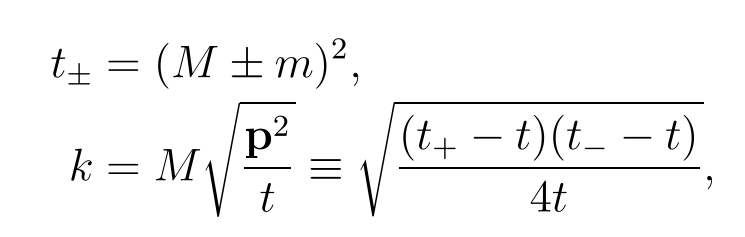

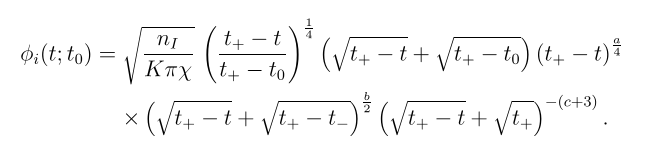

for B to K transition $n_I = 2$

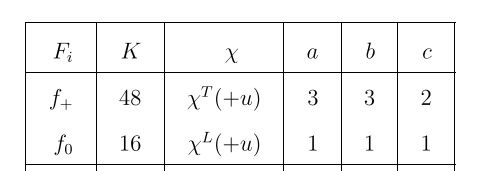

In [18]:
def phi_general(s, nI, K, m, M, t0, a, b, c, Q2, s0):
    t_plus = (M + m)**2
    t_minus = (M - m)**2

    sqrt_s = np.sqrt(t_plus - s)
    sqrt_t0 = np.sqrt(t_plus - t0)
    sqrt_t_minus = np.sqrt(t_plus - t_minus)
    sqrt_0 = np.sqrt(t_plus)

    return np.sqrt(nI / (K * np.pi * chi.chi_OPE(Q2, s0))) * np.sqrt(sqrt_s / sqrt_t0) * (sqrt_s + sqrt_t0) * np.power(sqrt_s, a/4.0) * np.power(sqrt_s - sqrt_t_minus, b/2.0) * np.power(sqrt_s + sqrt_0, -c-3.0)

In [19]:
def phi_B_K(s, t0, Q2 = 0, s0 = (chi.mb + chi.ms)**2):
    pp = eos.Parameters.Defaults()
    pp.set('mass::B_d', 5.27931)
    pp.set('mass::K_d', 0.493677)

    m = pp['mass::K_d'].evaluate()
    M = pp['mass::B_d'].evaluate()

    nI = 2.0
    K = 48.0
    a = 3.0
    b = 3.0
    c = 2.0
    return phi_general(s, nI, K, m, M, t0, a, b, c, Q2, s0)

In [20]:
print(phi_B_K(0, 0))

TypeError: can't multiply sequence by non-int of type 'float'